# XGBoost forest structure — cross-dataset comparison

Reads `processed_capability_results/xgb_capability_comparison.csv` from `xgb_capability_comparison.py`.

**Aggregation:** All reported **structure and accuracy metrics** are **averaged over CV folds** for each triple `(dataset, n_estimators, max_depth)`. Line plots show **mean ± 1·std** across folds (std is 0 when only one fold exists). The table in the next section records **`n_folds`** per grid cell so you can confirm fold coverage.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

def resolve_xgb_csv_path() -> Path:
    """Find xgb_capability_comparison.csv whether cwd is repo root or analysis/."""
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "processed_capability_results" / "xgb_capability_comparison.csv",
        cwd.parent / "processed_capability_results" / "xgb_capability_comparison.csv",
        cwd / ".." / "processed_capability_results" / "xgb_capability_comparison.csv",
    ]
    for p in candidates:
        p = p.resolve()
        if p.is_file():
            return p
    raise FileNotFoundError(
        "Could not find processed_capability_results/xgb_capability_comparison.csv. "
        "Run from repo root: python xgb_capability_comparison.py --home-dir . --overwrite-csv"
    )

CSV_PATH = resolve_xgb_csv_path()
print("CSV:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
required = {
    "dataset",
    "fold",
    "n_estimators",
    "max_depth",
    "total_leaves",
    "split_feature_entropy_bits",
    "test_acc",
}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

print("rows:", len(df), "| datasets:", sorted(df["dataset"].unique()), "| folds:", sorted(df["fold"].unique()))
df.head()


CSV: /Users/beliz/Desktop/thesis_project/SagiXGBoostTreeApproximator/processed_capability_results/xgb_capability_comparison.csv
rows: 270 | datasets: ['bidding', 'magic', 'raisin'] | folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,dataset,fold,trial_id,base_seed,random_state,n_estimators,max_depth,n_features,n_train_samples,fit_time_sec,...,test_acc,n_trees,total_leaves,mean_leaves_per_tree,std_leaves_per_tree,max_leaves_single_tree,mean_max_depth_per_tree,max_depth_any_tree,n_distinct_split_features,split_feature_entropy_bits
0,magic,0,0,42,42,10,3,10,9363,0.021532,...,0.791854,10,80,8.00,0.000000,8,3.0,3,8,2.552787
1,magic,0,0,42,42,10,4,10,9363,0.035337,...,0.802317,10,159,15.90,0.300000,16,4.0,4,7,2.594245
2,magic,0,0,42,42,10,5,10,9363,0.034330,...,0.818759,10,313,31.30,0.900000,32,5.0,5,9,2.829329
3,magic,0,0,42,42,20,3,10,9363,0.032186,...,0.805680,20,160,8.00,0.000000,8,3.0,3,8,2.628251
4,magic,0,0,42,42,20,4,10,9363,0.039099,...,0.819880,20,317,15.85,0.357071,16,4.0,4,10,2.847580


In [3]:
# Mean ± std over folds for each (dataset, n_estimators, max_depth)

METRIC_COLS = [
    "total_leaves",
    "mean_leaves_per_tree",
    "max_leaves_single_tree",
    "mean_max_depth_per_tree",
    "max_depth_any_tree",
    "n_distinct_split_features",
    "split_feature_entropy_bits",
    "fit_time_sec",
    "train_acc",
    "val_acc",
    "test_acc",
]

# How many folds contributed to each grid cell (should match your --folds grid)
fold_counts = (
    df.groupby(["dataset", "n_estimators", "max_depth"])["fold"]
    .nunique()
    .reset_index(name="n_folds")
)

agg = (
    df.groupby(["dataset", "n_estimators", "max_depth"])[METRIC_COLS]
    .agg(["mean", "std"])
)
agg.columns = ["_".join(col).strip() for col in agg.columns.values]
agg = agg.reset_index().merge(fold_counts, on=["dataset", "n_estimators", "max_depth"])

preview_cols = ["dataset", "n_estimators", "max_depth", "n_folds"] + [
    c for c in agg.columns if c.endswith("_mean")
][:6]
agg[preview_cols].head(12)


,dataset,n_estimators,max_depth,n_folds,total_leaves_mean,mean_leaves_per_tree_mean,max_leaves_single_tree_mean,mean_max_depth_per_tree_mean,max_depth_any_tree_mean,n_distinct_split_features_mean
0,bidding,10,3,5,79.2,7.920000,8.0,3.0,3.0,6.8
1,bidding,10,4,5,124.0,12.400000,14.4,4.0,4.0,8.6
2,bidding,10,5,5,159.0,15.900000,19.4,5.0,5.0,8.8
3,bidding,20,3,5,159.2,7.960000,8.0,3.0,3.0,7.4
4,bidding,20,4,5,250.4,12.520000,14.6,4.0,4.0,8.8
5,bidding,20,5,5,336.2,16.810000,20.8,5.0,5.0,8.8
6,bidding,40,3,5,303.6,7.590000,8.0,3.0,3.0,8.4
7,bidding,40,4,5,463.8,11.595000,14.6,4.0,4.0,8.8
8,bidding,40,5,5,614.2,15.355000,20.8,5.0,5.0,8.8
9,bidding,60,3,5,446.6,7.443333,8.0,3.0,3.0,8.4


In [4]:
# Quick check: uniform n_folds across the grid (optional)
vc = agg["n_folds"].value_counts().sort_index()
print("n_folds distribution:", vc.to_dict())
if agg["n_folds"].nunique() > 1:
    print("Note: some cells have fewer folds — means are still valid but compare carefully.")


n_folds distribution: {5: 54}


In [11]:
# --- Line plots: metrics vs n_estimators, one panel per max_depth, hue = dataset ---

datasets = sorted(agg["dataset"].unique())


def lineplot_by_depth(
    y_mean_col,
    y_std_col=None,
    *,
    title_y,
    ylabel,
    sharey=False,
    for_report=False,
):
    depths = sorted(agg["max_depth"].unique())
    if for_report:
        n_rows = len(depths)
        n_cols = 1
        figsize_dims = (6, 3 * len(depths))

    else:
        n_cols = len(depths)
        n_rows = 1
        figsize_dims = (5 * len(depths), 4.2)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize_dims,
        sharey=sharey,
        squeeze=False,
    )
    axes = axes.flatten()
    palette = sns.color_palette("Set1", n_colors=len(datasets))
    cmap = dict(zip(datasets, palette))

    for ax, d in zip(axes, depths):
        sub = agg[agg["max_depth"] == d]
        for ds in datasets:
            s = sub[sub["dataset"] == ds].sort_values("n_estimators")
            x = s["n_estimators"]
            y = s[y_mean_col]
            ax.plot(x, y, marker="o", label=ds, color=cmap[ds], linewidth=2)
            if y_std_col and y_std_col in s.columns:
                err = s[y_std_col].fillna(0)
                ax.fill_between(x, y - err, y + err, color=cmap[ds], alpha=0.15)
        ax.set_title(f"max_depth = {d}")
        ax.set_xlabel("n_estimators")
        ax.set_ylabel(ylabel)
        ax.legend(title="dataset")
    fig.suptitle(title_y + " (mean ± std over folds)", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


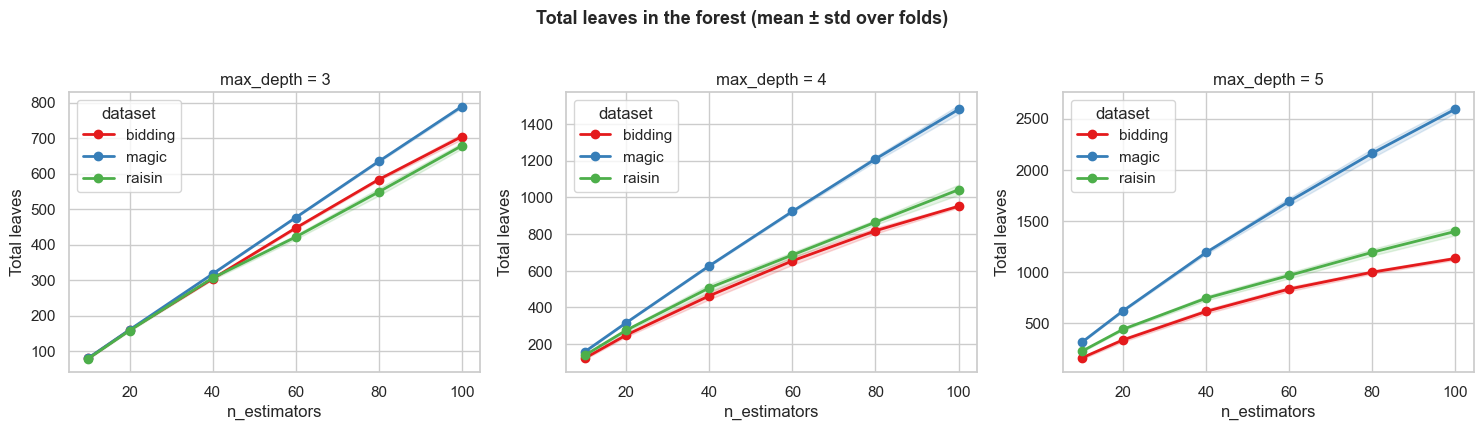

In [12]:
lineplot_by_depth(
    "total_leaves_mean",
    "total_leaves_std",
    title_y="Total leaves in the forest",
    ylabel="Total leaves",
)


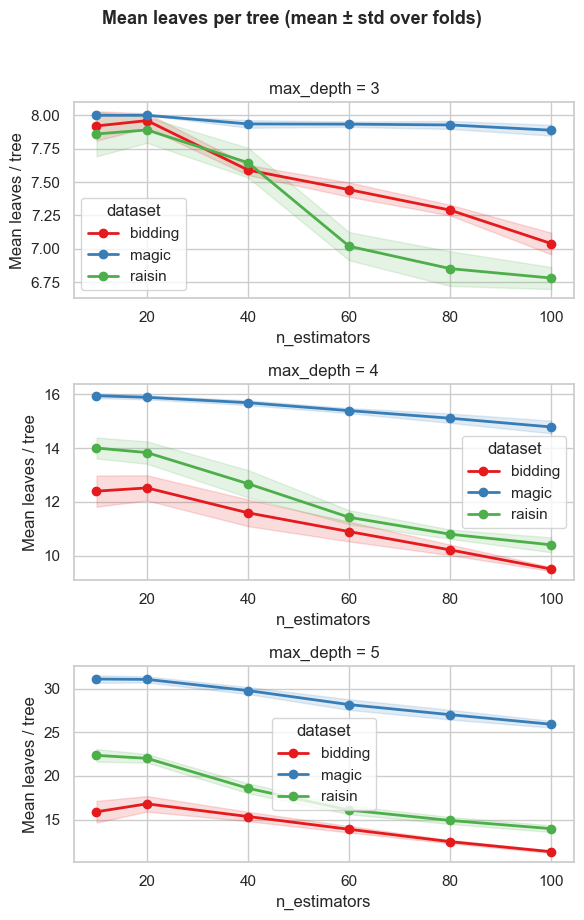

In [13]:
lineplot_by_depth(
    "mean_leaves_per_tree_mean",
    "mean_leaves_per_tree_std",
    title_y="Mean leaves per tree",
    ylabel="Mean leaves / tree",
    for_report=True,
)


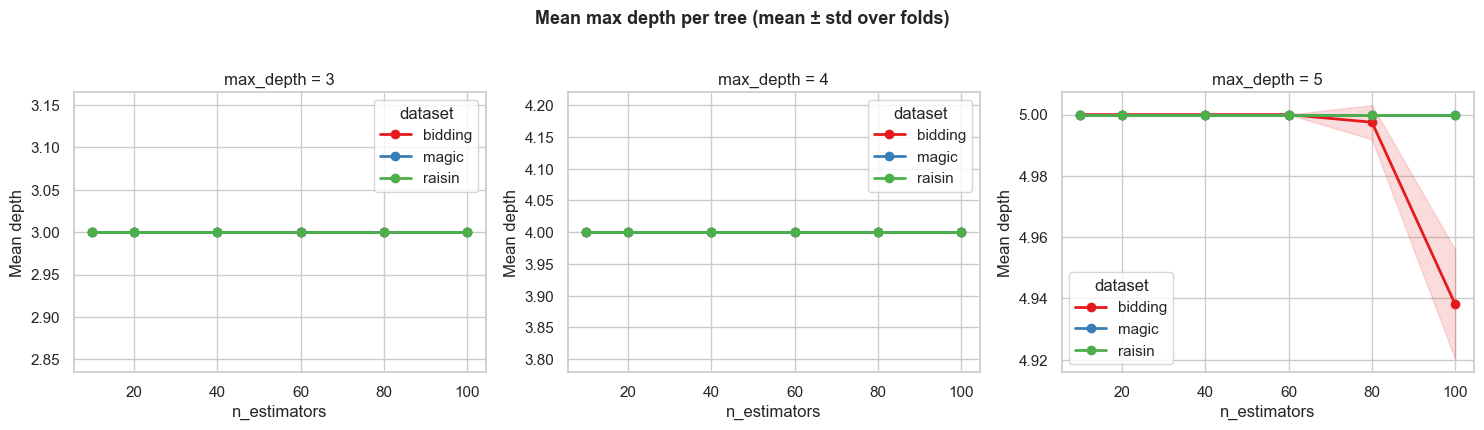

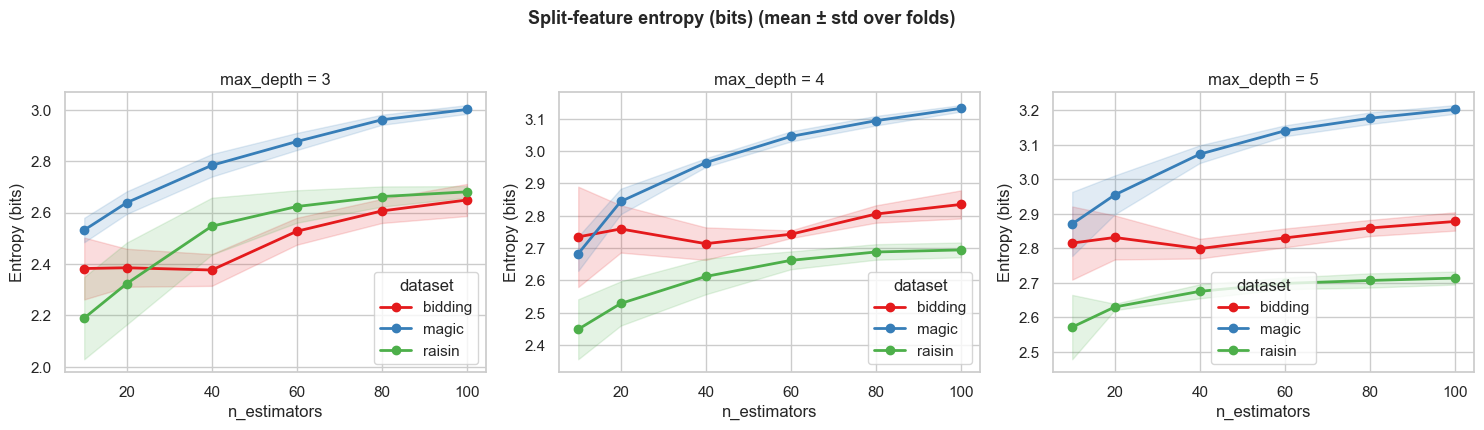

In [7]:
lineplot_by_depth(
    "mean_max_depth_per_tree_mean",
    "mean_max_depth_per_tree_std",
    title_y="Mean max depth per tree",
    ylabel="Mean depth",
)
lineplot_by_depth(
    "split_feature_entropy_bits_mean",
    "split_feature_entropy_bits_std",
    title_y="Split-feature entropy (bits)",
    ylabel="Entropy (bits)",
)


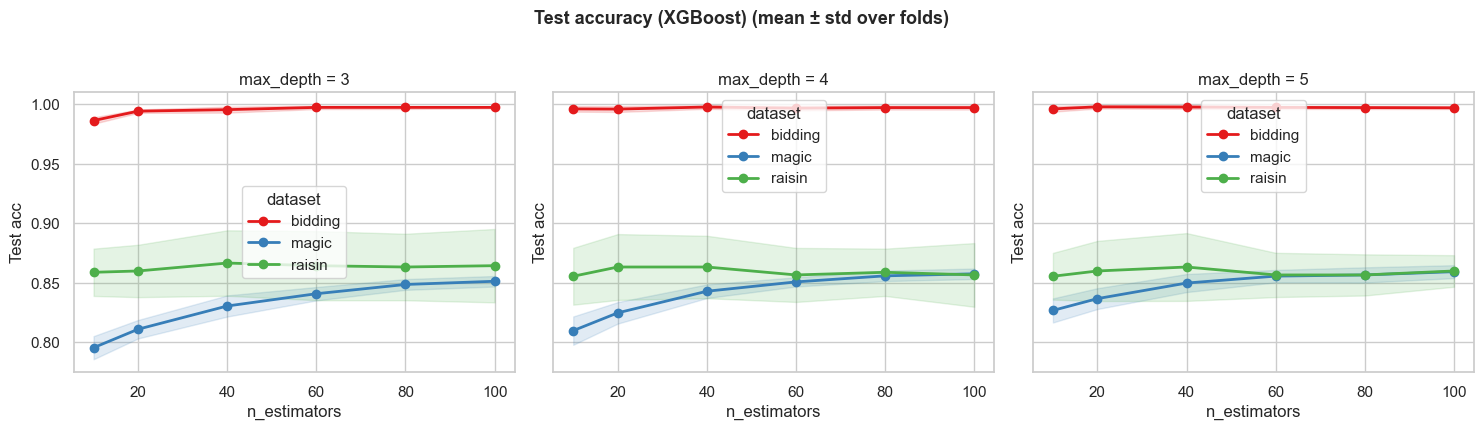

In [8]:
lineplot_by_depth(
    "test_acc_mean",
    "test_acc_std",
    title_y="Test accuracy (XGBoost)",
    ylabel="Test acc",
    sharey=True,
)


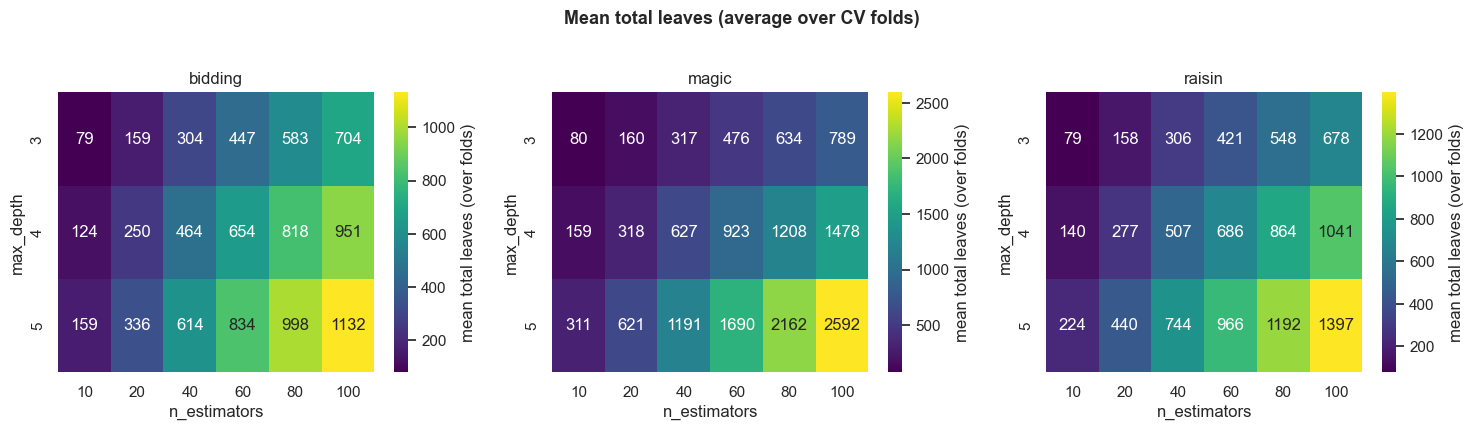

In [9]:
# --- Heatmaps: mean total_leaves (averaged over folds) ---

pivot_tables = {}
for ds in datasets:
    p = (
        agg[agg["dataset"] == ds]
        .pivot(index="max_depth", columns="n_estimators", values="total_leaves_mean")
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    pivot_tables[ds] = p

fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4.2))
if len(datasets) == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    sns.heatmap(
        pivot_tables[ds],
        ax=ax,
        annot=True,
        fmt=".0f",
        cmap="viridis",
        cbar_kws={"label": "mean total leaves (over folds)"},
    )
    ax.set_title(ds)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("max_depth")
fig.suptitle("Mean total leaves (average over CV folds)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


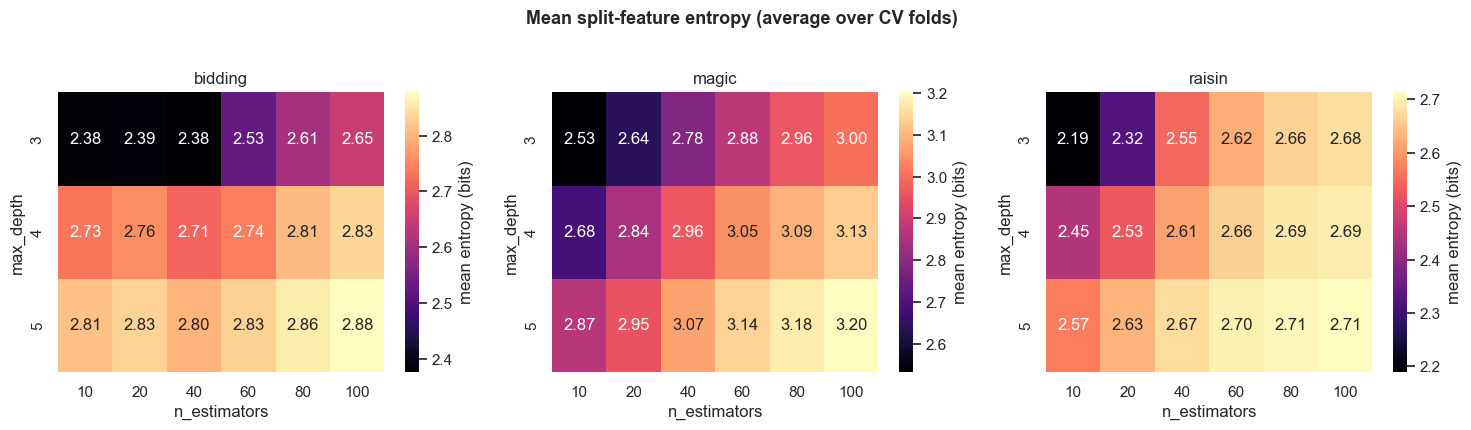

In [10]:
# --- Heatmaps: mean split_feature_entropy_bits (over folds) ---

fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4.2))
if len(datasets) == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    p = (
        agg[agg["dataset"] == ds]
        .pivot(index="max_depth", columns="n_estimators", values="split_feature_entropy_bits_mean")
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    sns.heatmap(
        p,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="magma",
        cbar_kws={"label": "mean entropy (bits)"},
    )
    ax.set_title(ds)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("max_depth")
fig.suptitle("Mean split-feature entropy (average over CV folds)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


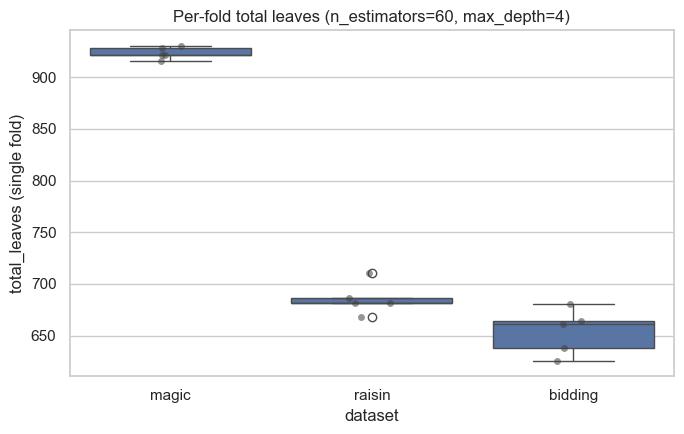

In [11]:
# --- Per-fold spread at one grid point (raw df, not fold-averaged) ---

pick_n, pick_d = 60, 4
sub = df[(df["n_estimators"] == pick_n) & (df["max_depth"] == pick_d)]
if len(sub) < 3:
    pick_n = int(df["n_estimators"].median())
    pick_d = int(df["max_depth"].median())
    sub = df[(df["n_estimators"] == pick_n) & (df["max_depth"] == pick_d)]

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=sub, x="dataset", y="total_leaves")
sns.stripplot(data=sub, x="dataset", y="total_leaves", color="0.25", alpha=0.55, jitter=0.12)
plt.ylabel("total_leaves (single fold)")
plt.title(f"Per-fold total leaves (n_estimators={pick_n}, max_depth={pick_d})")
plt.tight_layout()
plt.show()
